# [1.3.1] Linear probes ② — 성공을 증거로 만들기: 대조군과 통계

①의 관찰(C1)은 "무엇인가가 layer 12에서 선형으로 읽힌다"이다. 논문 저자는 여기서 reviewer가 던질 질문을 **먼저** 던진다.

> 대조군의 목적은 "내 결과가 맞다"를 보이는 것이 아니다. **같은 숫자를 만드는 다른 설명이 틀렸다**를 보이는 것이다.

그래서 대조군마다 순서가 같다. ① 대안 설명을 쓴다 → ② 그 설명이 참이라면 어떤 숫자가 나와야 하는지 **미리** 쓴다 → ③ 실험한다 → ④ 어느 설명이 약해졌는지만 말한다.

이 notebook은 ①의 대안 설명 표에서 세 줄을 맡는다.

| 기호 | 대안 설명 | 이 설명이 참이라면 | 실험 |
|---|---|---|---|
| A3 | 표면 통계 | 국가 이름이나 단어 분포만 쓰는 분류기도 높은 AUROC를 낸다 | 1️⃣ country one-hot, bag-of-embeddings |
| A5 | 확률·그럴듯함 | probe score는 모델이 문장에 주는 확률과 같은 정보를 담는다(같은 class 안에서도 상관) | 2️⃣ 모델의 판단, 국가 log-prob |
| A4 | probe 용량 | 무작위 weight의 모델에서도, 섞은 label에서도 비슷한 AUROC가 나온다 | 3️⃣ random-init 모델, 4️⃣ label을 섞은 귀무분포 |

## 학습 목표, 필수 경로, stop rule

1. 대조군마다 "대안 설명이 참이라면 나올 숫자"를 실험 **전에** 적는다.
2. label을 섞은 귀무분포가 MM probe에서 왜 0과 1 양끝에 몰리는지 식으로 설명한다. (**이 notebook의 핵심**)
3. permutation p-value, bootstrap 구간, split seed 반복이 각각 **어떤 불확실성**을 다루는지 구분한다.

### ③으로 넘어가도 되는 기준

- "MM probe의 shuffled-label 대조군에서 p ≈ 0.1이 나왔다"를 보고 "probe가 실패했다"고 읽으면 안 되는 이유를 말할 수 있다.
- 모델이 이미 행동으로 (거의) 다 맞히는 데이터에서 probe가 무엇을 새로 알려 주는지(또는 알려 주지 않는지) 말할 수 있다.

> **이전 판 교재의 미해결 문제.** 이 저장소의 이전 판(`study/linear_probes_ko`, Llama-2-13B)에서는 MM probe의 label을 섞은 대조군 20회가 AUROC 0~1에 퍼졌고 그중 3회가 1.0이었다. 본문은 이 분포를 해석하지 않았다. 4️⃣가 같은 현상을 재현하고, 그것이 버그가 아니라 **데이터의 공분산 구조**에서 나온다는 것을 보인다.

## 공통 setup

#### Cell 01 · 실행 환경과 공통 import

- **이번 셀의 질문:** ①과 같은 환경인가?
- **출력에서 볼 것:** 버전과 GPU를 확인한다.
- **해석 범위:** 환경 확인만 한다.
- **다음 단계의 목적:** 모델을 불러오고 ①의 split과 probe를 그대로 재현한다.

In [1]:
# 공통 setup — import는 이 셀 한 곳에서만 한다.
from __future__ import annotations

import gc
import sys
from importlib.metadata import version
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():  # 저장소 root 등 다른 위치에서 연 경우
    HERE = next(
        p
        for p in [HERE / "chapter1_transformer_interp/exercises/part31_linear_probes_ko", *HERE.parents]
        if (p / "probe_lab.py").exists()
    )
sys.path.insert(0, str(HERE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import probe_lab as pl
import tests

pl.use_style()
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print({
    "torch": torch.__version__,
    "transformers": version("transformers"),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "model": pl.DEFAULT_MODEL,
})

{'torch': '2.11.0+cu128', 'transformers': '5.18.0', 'gpu': 'NVIDIA RTX A6000', 'model': 'meta-llama/Llama-3.1-8B-Instruct'}


#### Cell 02 · 모델과 ①의 설정 재현

- **이번 셀의 질문:** ①과 똑같은 split·층·probe를 다시 만들 수 있는가?
- **출력에서 볼 것:** split 크기 898/300/298, `PROBE_LAYER = 12`, test AUROC가 MM·LR 모두 1.000인지 본다.
- **해석 범위:** ①의 결과 파일에서 층을 읽어 온다. 여기서 층을 다시 고르지 않는다(선택 편향 방지).
- **다음 단계의 목적:** 첫 번째 대안 설명, 표면 통계(A3)를 검사한다.

In [2]:
model, tok = pl.load_model(pl.DEFAULT_MODEL)
store = pl.ActivationStore(model=model, tokenizer=tok)
N_LAYERS = len(pl.decoder_layers(model))
print({"layers": N_LAYERS, "d_model": model.config.hidden_size,
       "dtype": str(next(model.parameters()).dtype),
       "GPU GiB": round(torch.cuda.memory_allocated() / 2**30, 1) if torch.cuda.is_available() else None})

cities = pl.load_dataset("cities")
y = cities["label"].to_numpy()
groups = cities["group"].to_numpy()
split = pl.group_split(groups, seed=0)
tr, va, te = split.train, split.val, split.test

PROBE_LAYER = pl.load_results("01_observation")["probe_layer"]
X = store.dataset("cities", [PROBE_LAYER])[PROBE_LAYER]
mm = pl.fit_mass_mean(X[tr], y[tr])
lr = pl.fit_logistic(X[tr], y[tr], C=0.1)
print({"split": (len(tr), len(va), len(te)), "PROBE_LAYER": PROBE_LAYER,
       "MM test AUROC": pl.auroc(y[te], mm.score(X[te])), "LR test AUROC": pl.auroc(y[te], lr.score(X[te]))})

{'layers': 32, 'd_model': 4096, 'dtype': 'torch.bfloat16', 'GPU GiB': 15.0}


{'split': (898, 300, 298), 'PROBE_LAYER': 12, 'MM test AUROC': 1.0, 'LR test AUROC': 1.0}


# 1️⃣ 표면 통계 (A3)

**대안 설명.** cities의 거짓 문장은 국가를 무작위로 골라 만들었다. 그러면 참 문장에는 큰 나라(중국, 인도)가 더 자주 나오고, probe는 "중국이 나오면 참"만 배워도 우연보다 잘 맞힐 수 있다. 더 일반적으로, 어떤 단어가 들어 있는지만 보고 맞힐 수도 있다.

**이 설명이 참이라면:** 국가 이름 하나만 쓰는 분류기, 또는 문장의 token embedding 평균(bag-of-embeddings)만 쓰는 선형 분류기도 높은 AUROC를 내야 한다.

#### Cell 03 · 국가별 참 비율

- **이번 셀의 질문:** 국가 이름이 정답에 대한 정보를 얼마나 주는가?
- **출력에서 볼 것:** 중국은 337번 나오고 그중 57%가 참이다. 대부분의 국가는 0.4–0.6이다.
- **해석 범위:** 약한 prior가 있다는 것을 확인했을 뿐이다. 이 prior를 쓰는 분류기의 실제 성능은 다음 셀에서 잰다.
- **다음 단계의 목적:** 국가 one-hot과 bag-of-embeddings baseline을 학습한다.

In [3]:
prior = cities.groupby("country")["label"].agg(["mean", "size"]).sort_values("size", ascending=False)
display(prior.head(8).T)

country,China,India,Russia,Brazil,Japan,South Korea,Mexico,Indonesia
mean,0.57,0.483,0.473,0.493,0.412,0.375,0.511,0.525
size,337.00,176.000,74.000,69.000,51.000,48.000,45.000,40.000


### ✏️ Exercise 3 · bag-of-embeddings 특징 만들기

> 난이도 🔴⚪⚪⚪⚪ · 중요도 🔵🔵🔵⚪⚪ · 10분

각 문장을 **문맥 없이** 표현한다: BOS를 뺀 token들의 입력 embedding(`model.model.embed_tokens`) 평균. 이 특징 위의 선형 분류기는 "어떤 단어들이 들어 있는가"만 볼 수 있고, "이 도시와 이 국가가 **짝이 맞는가**"는 계산할 수 없다(두 단어의 상호작용 항이 없다).

In [4]:
# Scratch — 직접 구현해 본다(테스트 없음, 아래 reference와 비교).
def my_bag_of_embeddings(model, tokenizer, texts) -> np.ndarray:
    """Returns: [N, D] numpy, 각 문장의 (BOS 제외) token embedding 평균."""
    raise NotImplementedError

#### Cell 04 · 표면 통계 baseline: country one-hot, bag-of-embeddings

- **이번 셀의 질문:** 국가 이름 또는 단어 구성만으로 참/거짓을 맞힐 수 있는가?
- **출력에서 볼 것:** 저장된 출력에서 두 baseline의 test AUROC는 0.46–0.48로 우연 수준이다. layer 12 probe(1.000)와 비교한다.
- **해석 범위:** A3가 크게 약해졌다. 단, 이것은 **선형** 표면 baseline이다. 처음 보는 도시의 정답 국가는 지리 지식 없이는 알 수 없으므로, 남는 표면 경로는 국가 prior뿐이고 그것이 거의 정보가 없다는 뜻이다. 국가 prior가 약하다는 것은 이 데이터셋 구성의 성질이기도 하다(③에서 다른 데이터셋으로 넓힌다).
- **다음 단계의 목적:** 두 번째 대안 설명, '확률·그럴듯함'(A5)을 검사한다.

In [5]:
@torch.inference_mode()
def bag_of_embeddings(model, tokenizer, texts) -> np.ndarray:
    """BOS를 뺀 token embedding 평균. Returns: [N, D]."""
    E = model.model.embed_tokens.weight
    feats = []
    for t in texts:
        ids = tokenizer(t, add_special_tokens=False, return_tensors="pt")["input_ids"][0].to(E.device)
        feats.append(E[ids].float().mean(0).cpu().numpy())
    return np.stack(feats)


country_onehot = pd.get_dummies(cities["country"]).to_numpy(dtype=np.float32)
bow = bag_of_embeddings(model, tok, cities["statement"].tolist())

rows = []
for name, F in [("country one-hot", country_onehot), ("bag-of-embeddings", bow), (f"layer {PROBE_LAYER} activation", X)]:
    probe = pl.fit_logistic(F[tr], y[tr], C=0.1)
    rows.append({"features": name, "dim": F.shape[1],
                 "val AUROC": pl.auroc(y[va], probe.score(F[va])), "test AUROC": pl.auroc(y[te], probe.score(F[te]))})
surface = pd.DataFrame(rows)
display(surface)

,features,dim,val AUROC,test AUROC
0,country one-hot,108,0.476,0.460
1,bag-of-embeddings,4096,0.478,0.475
2,layer 12 activation,4096,1.000,1.000


# 2️⃣ 모델 자신의 판단과 문장 확률 (A5)

**대안 설명.** probe는 "참"이 아니라 "모델이 보기에 그럴듯한 문장"을 표시할 수 있다. cities에서는 참 문장이 곧 그럴듯한 문장이라 두 성질이 겹친다.

두 가지를 잰다.

1. **모델의 행동:** few-shot prompt 뒤에 `This statement is:`를 붙이고 다음 token의 $P(\text{TRUE}) - P(\text{FALSE})$를 본다.
2. **국가 log-prob:** `The city of X is in` 뒤에 실제 국가 이름 ` Y.`가 이어질 log 확률.

**이 설명이 참이라면:** probe score는 log-prob과 **같은 class 안에서도** 강하게 상관되어야 한다. 참 문장끼리 비교해도, 더 그럴듯한 참 문장이 더 높은 probe score를 받아야 한다.

#### Cell 05 · 모델의 행동: few-shot TRUE/FALSE

- **이번 셀의 질문:** 모델은 probe 없이도 이 문장들의 참/거짓을 아는가?
- **출력에서 볼 것:** few-shot prompt의 모양과, test에서의 행동 정확도(저장된 출력 1.000), AUROC 1.000, P(TRUE)+P(FALSE)≈0.998을 본다. few-shot 예시의 도시·단어는 이 장의 어느 데이터셋에도 없는 것으로 골랐다.
- **해석 범위:** 모델이 이미 행동으로 맞히므로, cities에서의 probe는 **숨은 지식을 새로 드러내지 않는다.** 이 probe의 과학적 가치는 '모델이 아는가'가 아니라 '그 정보가 **어디에, 어떤 형태로** 있는가'에 있다. 행동과 내부 상태가 어긋나는 경우는 ⑧에서 다룬다.
- **다음 단계의 목적:** 국가 이름의 log-prob을 계산해 probe score와 비교한다.

In [6]:
print(pl.FEW_SHOT_PROMPT + cities["statement"].iloc[te[0]] + pl.SUFFIX, "<next token?>")
behavior = pl.true_false_margin(model, tok, pl.build_prompts(cities["statement"].tolist()))
print({"test behavior acc": pl.accuracy(y[te], behavior["p_diff"][te]),
       "test behavior AUROC": pl.auroc(y[te], behavior["logit_diff"][te]),
       "mean P(TRUE)+P(FALSE)": float(behavior["p_sum"][te].mean())})

The city of Bergen is in Norway. This statement is: TRUE
The city of Graz is in Brazil. This statement is: FALSE
The Spanish word 'queso' means 'cheese'. This statement is: TRUE
The Spanish word 'espejo' means 'rain'. This statement is: FALSE
The city of Abidjan is in Côte d'Ivoire. This statement is: <next token?>


{'test behavior acc': 1.0, 'test behavior AUROC': 1.0, 'mean P(TRUE)+P(FALSE)': 0.9984847903251648}


#### Cell 06 · 국가 log-prob과 probe score의 관계

- **이번 셀의 질문:** probe score는 '모델이 이 국가를 얼마나 그럴듯하게 보는가'의 다른 표현인가?
- **출력에서 볼 것:** 저장된 출력: 국가 log-prob 자체도 test AUROC 1.000이다. 전체 상관은 0.88로 높지만, **같은 class 안에서는** 참 0.04, 거짓 −0.05로 거의 0이다. 그림에서 두 덩어리 각각의 안쪽은 기울기가 없다.
- **해석 범위:** 전체 상관 0.88은 두 변수가 모두 label을 따라가기 때문에 생긴 것이다. class 안에서 상관이 없으므로 probe는 log-prob의 선형 대리값이 아니다. A5가 **약해졌지만** 배제되지는 않았다. 부정문에서는 '그럴듯함'과 '참'이 갈라진다. 그 시험은 ⑥에 있다.
- **다음 단계의 목적:** 세 번째 대안 설명(A4)으로 간다. 먼저 무작위 weight 모델에서 같은 실험을 한다.

{'country log-prob test AUROC': 1.0, 'corr all': 0.877, 'corr within true': 0.045, 'corr within false': -0.045}


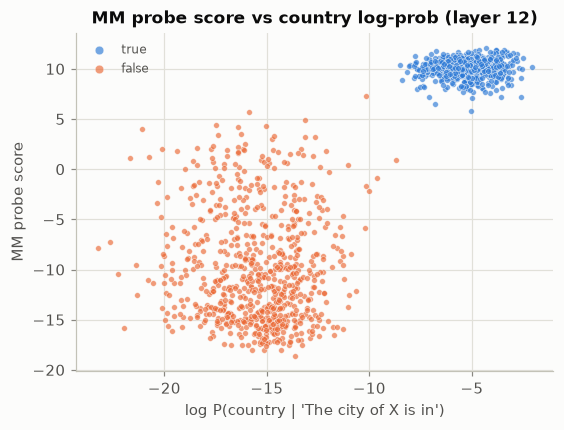

In [7]:
@torch.inference_mode()
def continuation_logprob(model, tokenizer, prefixes, continuations, batch_size: int = 32) -> np.ndarray:
    """log P(continuation | prefix)의 token 합. prefix 뒤에 continuation을 붙인 전체 문장을 한 번 forward한다."""
    out = []
    device = next(model.parameters()).device
    for s in range(0, len(prefixes), batch_size):
        P, C = prefixes[s : s + batch_size], continuations[s : s + batch_size]
        enc = tokenizer([p + c for p, c in zip(P, C)], return_tensors="pt", padding=True).to(device)
        n_prefix = [len(tokenizer(p)["input_ids"]) for p in P]
        logp = model(**enc).logits.float().log_softmax(-1)
        for b in range(len(P)):
            L = int(enc["attention_mask"][b].sum())
            target = enc["input_ids"][b, n_prefix[b] : L]
            out.append(logp[b, n_prefix[b] - 1 : L - 1].gather(-1, target[:, None]).sum().item())
    return np.array(out)


prefixes = [f"The city of {c} is in" for c in cities["city"]]
conts = [f" {c}." for c in cities["country"]]
assert all(p + c == s for p, c, s in zip(prefixes, conts, cities["statement"]))
country_lp = continuation_logprob(model, tok, prefixes, conts)

s_mm = mm.score(X)
corr = {"all": np.corrcoef(s_mm, country_lp)[0, 1],
        "within true": np.corrcoef(s_mm[y == 1], country_lp[y == 1])[0, 1],
        "within false": np.corrcoef(s_mm[y == 0], country_lp[y == 0])[0, 1]}
print({"country log-prob test AUROC": pl.auroc(y[te], country_lp[te]), **{f"corr {k}": round(float(v), 3) for k, v in corr.items()}})

fig, ax = plt.subplots(figsize=(5.6, 4))
pl.scatter_classes(ax, np.c_[country_lp, s_mm], y, title=f"MM probe score vs country log-prob (layer {PROBE_LAYER})",
                   xlabel="log P(country | 'The city of X is in')", ylabel="MM probe score")
plt.show()

# 3️⃣ random-init 모델 (A4, 첫 번째 검사)

**대안 설명.** 4096차원 선형 probe는 강력하다. 학습되지 않은 무작위 네트워크의 activation에서도, 단어들이 섞인 흔적만으로 비슷한 성능이 나올 수 있다. 이것이 "probe가 계산을 대신했다"는 걱정이다. 무작위 encoder baseline은 오래된 대조군이다([Zhang & Bowman 2018](https://arxiv.org/abs/1809.10040): 학습하지 않은 무작위 LSTM도 통사 probe에서 놀랄 만큼 잘했다).

**이 설명이 참이라면:** 같은 구조·같은 tokenizer에 무작위 weight를 넣은 모델에서도 어느 층에서든 높은 AUROC가 나와야 한다.

**메모리:** 학습된 모델을 먼저 내리고 무작위 모델을 올린다. 두 8B 모델을 동시에 올리지 않는다.

#### Cell 07 · 무작위 weight 모델에서 층 sweep

- **이번 셀의 질문:** 학습되지 않은 같은 구조의 네트워크에서도 참/거짓이 선형으로 읽히는가?
- **출력에서 볼 것:** 저장된 출력: 32개 층 전체에서 LR validation AUROC 최댓값이 약 0.58이다(학습된 모델은 layer 8 이후 1.000).
- **해석 범위:** probe의 용량과 구조만으로는 이 결과가 나오지 않는다. 0.5보다 약간 높은 값은 국가 prior 같은 약한 표면 정보가 무작위 attention을 통해 섞인 결과로 보인다. 무작위 초기화 seed 하나의 결과다.
- **다음 단계의 목적:** A4의 두 번째 검사, label을 섞은 귀무분포로 간다. 여기부터는 cache된 activation만 쓴다.

max over layers: 0.578 at layer 0


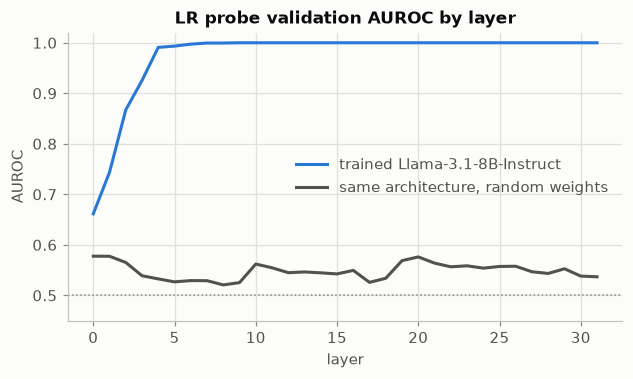

In [8]:
store.model = None          # store도 모델을 참조하므로 함께 놓아야 GPU 메모리가 반환된다
del model
gc.collect()
torch.cuda.empty_cache()

rand_model = pl.random_init_model(pl.DEFAULT_MODEL, seed=0)
rand_store = pl.ActivationStore(model_id="random-init/Llama-3.1-8B", model=rand_model, tokenizer=tok)
LAYERS = list(range(32))
rand_acts = rand_store.get("cities", cities["statement"].tolist(), LAYERS)

rand_rows = []
for l in LAYERS:
    Xr = rand_acts[l]
    p = pl.fit_logistic(Xr[tr], y[tr], C=0.1)
    rand_rows.append({"layer": l, "random-init LR val AUROC": pl.auroc(y[va], p.score(Xr[va]))})
rand_sweep = pd.DataFrame(rand_rows).set_index("layer")
print("max over layers:", round(rand_sweep.iloc[:, 0].max(), 3), "at layer", int(rand_sweep.iloc[:, 0].idxmax()))

trained = pd.DataFrame(pl.load_results("01_observation")["sweep"]).set_index("layer")
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(trained.index, trained["LR AUROC"], color=pl.C_TRUE, label="trained Llama-3.1-8B-Instruct")
ax.plot(rand_sweep.index, rand_sweep.iloc[:, 0], color=pl.INK2, label="same architecture, random weights")
ax.axhline(0.5, color=pl.MUTED, lw=1, ls=":")
ax.set(title="LR probe validation AUROC by layer", xlabel="layer", ylabel="AUROC", ylim=(0.45, 1.02))
ax.legend(loc="center right")
plt.show()

del rand_model
gc.collect()
torch.cuda.empty_cache()

# 4️⃣ label을 섞은 귀무분포 (A4, 두 번째 검사) — 이 notebook의 핵심

**permutation test의 논리.** 귀무가설 $H_0$: "label은 activation과 무관하다." $H_0$가 참이면 train label을 아무렇게나 섞어도 학습 절차가 내는 test 성능의 분포는 같다. 그래서

1. train label을 섞는다(test label은 그대로 둔다).
2. 같은 절차로 probe를 다시 학습하고 test AUROC를 잰다.
3. 이것을 $n$번 반복한 분포가 **귀무분포**다.
4. p-value $= \dfrac{1 + \#\{\text{null} \ge \text{observed}\}}{1 + n}$. 분자·분모의 +1 때문에 $n$번으로 얻을 수 있는 가장 작은 p는 $1/(n+1)$이다.

**이 설명(A4)이 참이라면:** 섞은 label로 학습한 probe도 test에서 종종 높은 AUROC를 내고, 실제 probe의 1.000은 귀무분포의 꼬리에 있지 않을 것이다.

#### Cell 08 · Scratch: 귀무분포의 모양 예측

- **이번 셀의 질문:** MM probe와 LR probe 각각에서, 섞은 label로 학습한 probe의 test AUROC 분포는 어떤 모양일까?
- **출력에서 볼 것:** 빈 셀이다. 평균과 퍼짐을 각각 예측해 적는다.
- **해석 범위:** 대부분의 사람은 '둘 다 0.5 근처에 좁게 모인다'고 예측한다. 그 예측이 맞는지 본다.
- **다음 단계의 목적:** permutation_null을 직접 구현한다.

In [9]:
# 예측:
#   MM null: 평균 ≈ ?, 표준편차 ≈ ?, 모양:
#   LR null: 평균 ≈ ?, 표준편차 ≈ ?, 모양:

### ✏️ Exercise 4 · `permutation_null` 구현

> 난이도 🔴🔴⚪⚪⚪ · 중요도 🔵🔵🔵🔵⚪ · 10~15분

`fit(X, y) -> LinearProbe`를 받아 train label만 섞어 `n_perm`번 다시 학습하고, **섞지 않은** test label에 대한 AUROC 배열을 돌려준다. 재현 가능하도록 `np.random.default_rng(seed)`를 쓴다.

In [10]:
# Scratch
MY_IMPL = False

def my_permutation_null(fit, X_train, y_train, X_test, y_test, n_perm: int = 100, seed: int = 0) -> np.ndarray:
    raise NotImplementedError

if MY_IMPL:
    tests.test_permutation_null(my_permutation_null)

#### Cell 09 · Reference 구현과 실제 귀무분포 (MM 200회, LR 100회)

- **이번 셀의 질문:** 실제 probe의 test AUROC 1.000은 각 귀무분포의 꼬리에 있는가?
- **출력에서 볼 것:** 저장된 출력: **MM 귀무분포는 양끝에 몰린다** — 200회 중 30%가 AUROC ≥ 0.99, 31%가 ≤ 0.01이고 p ≈ 0.10이다. **LR 귀무분포는 0.5 근처에 좁다** — 평균 0.50, 표준편차 0.044, 범위 0.38–0.59, p ≈ 0.0099(100회로 얻을 수 있는 최솟값).
- **해석 범위:** MM의 p ≈ 0.10은 'probe가 실패했다'는 뜻이 **아니다**. 이 검정 통계량이 이 데이터에서 label이 없어도 극단값을 자주 낸다는 뜻이다. 왜 그런지가 다음 셀의 주제다.
- **다음 단계의 목적:** MM 귀무분포가 양끝에 몰리는 이유를 식과 실험으로 확인한다.

✅ permutation_null: shape OK, test label 보존, 무신호 평균 0.503


,mean,sd,min,max,P(null ≥ 0.99),P(null ≤ 0.01),observed,p-value
MM (200 perms),0.493,0.463,0.000,1.000,0.3,0.31,1.0,0.10
LR (100 perms),0.496,0.044,0.375,0.585,0.0,0.00,1.0,0.01


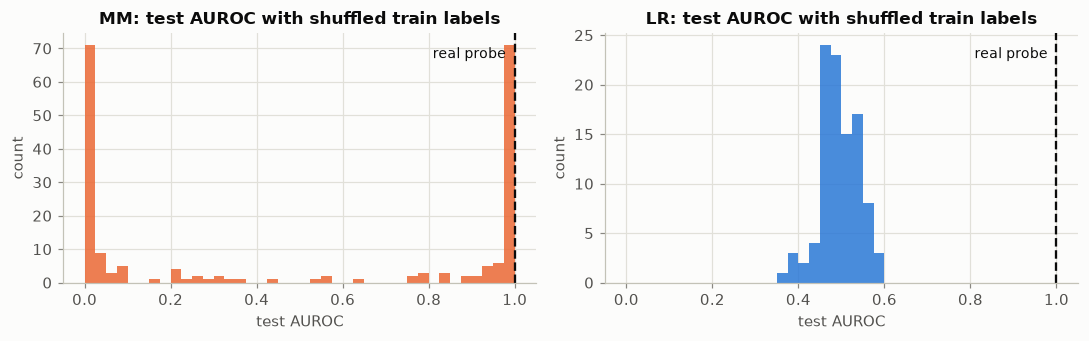

In [11]:
def permutation_null_reference(fit, X_train, y_train, X_test, y_test, n_perm=100, seed=0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        probe = fit(X_train, rng.permutation(y_train))   # train label만 섞는다
        null[i] = pl.auroc(y_test, probe.score(X_test))  # test label은 그대로
    return null


tests.test_permutation_null(permutation_null_reference)

null_mm = permutation_null_reference(pl.fit_mass_mean, X[tr], y[tr], X[te], y[te], n_perm=200, seed=1)
null_lr = permutation_null_reference(lambda a, b: pl.fit_logistic(a, b, C=0.1), X[tr], y[tr], X[te], y[te], n_perm=100, seed=1)
obs = {"MM": pl.auroc(y[te], mm.score(X[te])), "LR": pl.auroc(y[te], lr.score(X[te]))}


def describe(null: np.ndarray, observed: float) -> dict:
    return {"mean": null.mean(), "sd": null.std(), "min": null.min(), "max": null.max(),
            "P(null ≥ 0.99)": np.mean(null >= 0.99), "P(null ≤ 0.01)": np.mean(null <= 0.01),
            "observed": observed, "p-value": pl.permutation_p_value(null, observed)}


null_table = pd.DataFrame({"MM (200 perms)": describe(null_mm, obs["MM"]), "LR (100 perms)": describe(null_lr, obs["LR"])}).T
display(null_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=False)
for ax, null, name in [(axes[0], null_mm, "MM"), (axes[1], null_lr, "LR")]:
    ax.hist(null, bins=np.linspace(0, 1, 41), color=pl.C_TRUE if name == "LR" else pl.C_FALSE, alpha=0.85)
    ax.axvline(obs[name], color=pl.INK, lw=1.5, ls="--")
    ax.text(obs[name] - 0.02, ax.get_ylim()[1] * 0.9, "real probe", ha="right", color=pl.INK, fontsize=9)
    ax.set(title=f"{name}: test AUROC with shuffled train labels", xlabel="test AUROC", ylabel="count")
plt.tight_layout()
plt.show()

## 왜 MM 귀무분포는 양끝에 몰리는가

label을 섞으면 $\mu_1 - \mu_0$는 train 표본에 무작위 부호 가중치를 준 합이 된다.

$$\theta_{\text{shuffled}} = \frac1{n_1}\sum_{i \in \text{"1"}} x_i - \frac1{n_0}\sum_{i\in\text{"0"}} x_i = \sum_i c_i\,(x_i - \bar x), \qquad c_i = \pm\tfrac{2}{n}$$

무작위 부호 합은 (중심극한정리로) 대략 $\mathcal N(0, \tfrac{4}{n}\Sigma)$를 따른다. $\Sigma$는 **데이터 자체의 공분산**이다. 즉 섞은 label의 MM 방향은 "분산이 큰 방향일수록 더 크게 섞인" 무작위 방향이다.

①에서 layer 12의 PC1은 **분산의 56%** 를 설명하고 참/거짓을 완전히 갈랐다. 그러니 무작위 방향은 대부분 ±PC1 쪽으로 치우치고, 그 방향의 AUROC는 부호에 따라 0 아니면 1이 된다. 이 설명이 맞다면 두 가지가 성립해야 한다.

1. label을 전혀 쓰지 않고 $\mathcal N(0, \Sigma)$에서 방향을 뽑아도 MM 귀무분포와 같은 모양이 나온다.
2. 등방적인 $\mathcal N(0, I)$에서 뽑은 방향은 덜 극단적이다(그래도 PC1 성분 때문에 꽤 퍼진다).

#### Cell 10 · label 없이 무작위 방향만으로 귀무분포 재현

- **이번 셀의 질문:** MM 귀무분포의 양끝 쏠림은 label 섞기가 아니라 데이터 공분산 때문인가?
- **출력에서 볼 것:** 저장된 출력: N(0,Σ) 방향 500개는 36%가 ≥0.99, 34%가 ≤0.01로 MM 귀무분포(30%, 31%)와 같은 모양이다. 등방 방향은 표준편차 0.33으로 넓게 퍼지지만 ≥0.99는 3%뿐이다. PC1 하나의 test AUROC는 0.000(부호만 반대인 완전 분리)이다.
- **해석 범위:** label 정보는 이 축의 **부호(1비트)** 만 정해 준다. 이 데이터에서 MM probe의 성공은 '데이터가 이미 가장 크게 변하는 축을 찾고, label로 방향만 정했다'로 거의 설명된다.
- **다음 단계의 목적:** 이 결과가 무엇을 지지하고 무엇을 경고하는지 정리한다.

,mean,sd,P(null ≥ 0.99),P(null ≤ 0.01)
shuffled-label MM,0.493,0.463,0.300,0.310
"N(0, Σ) direction",0.510,0.470,0.358,0.340
"N(0, I) direction",0.516,0.332,0.032,0.028


PC1 explained variance: 0.559 | PC1 test AUROC: 0.0


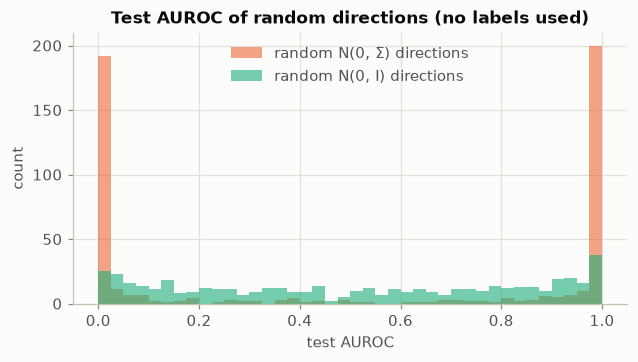

In [12]:
rng = np.random.default_rng(0)
Xc = X[tr] - X[tr].mean(0)
dirs_cov = rng.normal(size=(500, len(Xc))) @ Xc            # N(0, Σ)에 비례하는 방향 500개
dirs_iso = rng.normal(size=(500, X.shape[1]))              # 등방 N(0, I)
au_cov = np.array([pl.auroc(y[te], X[te] @ d) for d in dirs_cov])
au_iso = np.array([pl.auroc(y[te], X[te] @ d) for d in dirs_iso])
pca = pl.fit_pca(X[tr], k=3)

directions = pd.DataFrame({
    "shuffled-label MM": describe(null_mm, np.nan),
    "N(0, Σ) direction": describe(au_cov, np.nan),
    "N(0, I) direction": describe(au_iso, np.nan),
}).T[["mean", "sd", "P(null ≥ 0.99)", "P(null ≤ 0.01)"]]
display(directions)
print("PC1 explained variance:", round(float(pca.explained[0]), 3),
      "| PC1 test AUROC:", round(pl.auroc(y[te], pca.transform(X[te])[:, 0]), 3))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bins = np.linspace(0, 1, 41)
ax.hist(au_cov, bins=bins, color=pl.C_FALSE, alpha=0.6, label="random N(0, Σ) directions")
ax.hist(au_iso, bins=bins, color=pl.C_THIRD, alpha=0.6, label="random N(0, I) directions")
ax.set(title="Test AUROC of random directions (no labels used)", xlabel="test AUROC", ylabel="count")
ax.legend(loc="upper center")
plt.show()

### 학습 결론 — 대조군은 귀무분포를 봐야 읽힌다

1. **MM의 shuffled-label 검정은 여기서 검정력이 거의 없다.** label이 하는 일이 축의 부호를 정하는 것뿐이라, label 없는 절차도 절반 가까이 극단값을 낸다. p ≈ 0.10은 probe의 실패가 아니라 **이 통계량으로는 'label 덕분'과 '분산 구조 덕분'을 구분할 수 없다**는 뜻이다. 이전 판의 20회 중 3회 AUROC 1.0도 같은 현상이다. 그 경우 p는 (1+3)/(1+20) ≈ 0.19다.
2. **LR의 귀무분포는 좁다**(표준화와 L2 정규화가 PC1의 지배를 줄인다). 그래서 A4에 대한 결정적인 검사는 LR 쪽이다. p ≤ 0.01(100회의 최솟값).
3. **이 현상 자체가 하나의 발견이다.** layer 12에서 cities 문장들의 activation이 가장 크게 변하는 축이 참/거짓이다. Marks & Tegmark가 "PCA에서 label 없이 보인다"고 한 관찰의 강한 형태다.
4. **동시에 경고다.** 어떤 데이터에서 가장 큰 분산 축을 찾는 방법(PCA, label 없는 방법들)은 그 축이 무엇이든 찾는다. CCS 같은 비지도 방법이 '진실' 대신 가장 두드러진 다른 특징을 찾는다는 반례가 바로 이것이다([Farquhar et al. 2023](https://arxiv.org/abs/2312.10029)). 이 데이터에서 그 축이 진실과 겹친 것은 **데이터셋을 그렇게 만들었기 때문**일 수 있다. 템플릿이 고정된 문장들에서는 참/거짓 말고는 크게 변할 것이 없다.

일반 원칙: 대조군의 **평균**만 보지 말고 **분포**를 본다. 귀무분포는 데이터의 공분산과 probe family에 따라 모양이 다르다. 그리고 반복 횟수가 얻을 수 있는 최소 p를 정한다.

# 5️⃣ 불확실성 — 무엇을 재고 있는가

①의 bootstrap 구간은 [1.000, 1.000]으로 퇴화했다. 이 구간은 **고정된 probe**가 test 표본을 다르게 뽑았을 때 얼마나 흔들리는지만 잰다. 다른 종류의 불확실성은 따로 재야 한다.

| 불확실성 | 무엇이 바뀌는가 | 재는 방법 |
|---|---|---|
| 평가 표본 | 같은 probe, 다른 test 도시 | group bootstrap (①) |
| split·학습 | 어떤 도시가 train에 들어갔는가 | split seed 반복 (이 셀) |
| 선택 | 어떤 층이 뽑혔는가 | seed마다 층 선택 규칙을 다시 적용 (이 셀) |
| 모델 | 다른 모델, 다른 크기 | 이 장의 범위 밖 (한 모델) |

#### Cell 11 · split seed 5개에서 층 선택과 test 성능 반복

- **이번 셀의 질문:** split을 바꾸면 선택되는 층과 test 성능이 얼마나 흔들리는가?
- **출력에서 볼 것:** seed마다 d′ 규칙으로 고른 층(저장된 출력은 5개 모두 12)과 test AUROC(모두 1.000), MM accuracy(0.946–0.973)를 본다.
- **해석 범위:** 이 데이터에서 결과는 split에 둔감하다. 다만 모든 seed가 **같은 모델·같은 데이터셋**이므로, 이 안정성은 C1의 범위 안에서의 안정성이다.
- **다음 단계의 목적:** 주장 장부를 갱신하고 결과를 저장한다.

In [13]:
all_acts = store.dataset("cities", list(range(8, 17)))   # cache에서 읽는다
seed_rows = []
for seed in range(5):
    sp = pl.group_split(groups, seed=seed)
    dp = {l: pl.dprime(pl.fit_mass_mean(all_acts[l][sp.train], y[sp.train]), all_acts[l][sp.val], y[sp.val]) for l in all_acts}
    best = max(dp, key=dp.get)
    Xs = all_acts[best]
    m = pl.fit_mass_mean(Xs[sp.train], y[sp.train])
    l_ = pl.fit_logistic(Xs[sp.train], y[sp.train], C=0.1)
    seed_rows.append({"split seed": seed, "selected layer": best,
                      "MM test AUROC": pl.auroc(y[sp.test], m.score(Xs[sp.test])), "MM test acc": pl.accuracy(y[sp.test], m.score(Xs[sp.test])),
                      "LR test AUROC": pl.auroc(y[sp.test], l_.score(Xs[sp.test])), "LR test acc": pl.accuracy(y[sp.test], l_.score(Xs[sp.test]))})
seed_table = pd.DataFrame(seed_rows)
display(seed_table)

,split seed,selected layer,MM test AUROC,MM test acc,LR test AUROC,LR test acc
0,0,12,1.0,0.956,1.0,1.000
1,1,12,1.0,0.966,1.0,1.000
2,2,12,1.0,0.956,1.0,0.997
3,3,12,1.0,0.946,1.0,1.000
4,4,12,1.0,0.973,1.0,1.000


## 주장 장부 — ②의 갱신

| ID | 주장 | 근거 | 아직 배제하지 못한 설명 | 상태 |
|---|---|---|---|---|
| C1 | layer 12 마침표 위치에서 cities 문장의 참/거짓이 선형으로 거의 완전히 분리된다. | ① + split seed 5개에서 같은 결과 | A6, A7 | **지지됨** |
| C2 | 이 분리는 표면 통계(국가 prior, 단어 구성)나 probe의 용량으로 설명되지 않는다. | 표면 baseline 0.46–0.48, random-init 모델 최대 0.58, LR 귀무분포(평균 0.50, sd 0.044) 대비 p ≤ 0.01 | 비선형 표면 특징, 다른 데이터셋에서의 표면 통계 | **지지됨** |
| D1 | (기술적 발견) 이 데이터에서 참/거짓은 activation 분산이 가장 큰 축이다. | PC1이 분산 56%, 단독 AUROC 1.000. MM 귀무분포 = N(0,Σ) 방향 분포 | 데이터셋 구성(고정 템플릿) 때문일 가능성 | **관찰됨** |
| — | (보류) probe는 문장 확률의 대리값이다 (A5) | 국가 log-prob과 class 내 상관 ≈ 0 | 부정문처럼 확률과 참이 갈라지는 데이터 | **약화됨, 미결** |

**저자가 쓸 수 있는 문장:** "The truth of held-out city statements is linearly decodable from layer-12 residuals (test AUROC 1.00), and this is not explained by lexical baselines (≤0.48), a randomly initialized model (≤0.58), or probe capacity (LR permutation null 0.50 ± 0.04, p ≤ 0.01)."

**아직 쓸 수 없는 문장:** "the model represents truth" — 지금까지는 **한 데이터셋**의 한 템플릿이다. ③이 이 범위를 넓힌다.

#### Cell 12 · 결과 저장

- **이번 셀의 질문:** ⑤가 모아 읽을 대조군 수치를 기록한다.
- **출력에서 볼 것:** `results/02_controls.json` 경로가 출력된다.
- **해석 범위:** 귀무분포 원자료는 요약 통계만 저장한다.
- **다음 단계의 목적:** ③ 일반화 — 도시 문장으로 배운 방향이 다른 주제에서도 통하는가.

In [14]:
pl.save_results("02_controls", {
    "probe_layer": PROBE_LAYER,
    "surface_baselines": surface.to_dict(orient="records"),
    "behavior_test_acc": pl.accuracy(y[te], behavior["p_diff"][te]),
    "country_logprob_test_auroc": pl.auroc(y[te], country_lp[te]),
    "corr_probe_logprob": corr,
    "random_init_max_val_auroc": float(rand_sweep.iloc[:, 0].max()),
    "null": null_table.reset_index(names="probe").to_dict(orient="records"),
    "random_directions": directions.reset_index(names="kind").to_dict(orient="records"),
    "pc1_explained": float(pca.explained[0]),
    "seed_table": seed_table.to_dict(orient="records"),
    "claims": [
        {"id": "C1", "status": "지지됨", "text": "L12에서 cities 참/거짓이 선형으로 분리된다 (split seed 5개에서 재현)."},
        {"id": "C2", "status": "지지됨", "text": "표면 통계·probe 용량·무작위 weight로 설명되지 않는다 (baseline ≤0.48, random-init ≤0.58, LR null p≤0.01)."},
        {"id": "D1", "status": "관찰됨", "text": "참/거짓이 L12 activation의 최대 분산 축이다 (PC1 56%). MM shuffled-label 검정은 이 때문에 검정력이 없다."},
    ],
})

PosixPath('/workspace/ARENA_3.0/chapter1_transformer_interp/exercises/part31_linear_probes_ko/results/02_controls.json')